In [2]:
import os
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report , confusion_matrix , accuracy_score, auc

import tensorflow as tf
from tensorflow.keras.layers import Flatten, Conv2D, MaxPool2D, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
path = 'D:/Documentos/Diplomado_en_ciencia_de_datos/Modulo_6_Redes_neuronales/dataset'
weather = os.listdir(path)

counter = 1
weather_labels = {}
weather_image_paths = {}
images = []
labels = [] 

for weather_i in weather:
    weather_labels[weather_i] = counter
    weather_image_paths[weather_i] = os.listdir(f'{path}/{weather_i}/')[:232]
    counter += 1

df = pd.DataFrame(weather_image_paths)
#display(df)

for row in range(df.shape[0]):
    for column in range(df.shape[1]):
        weather = df.columns[column]
        image_name = df.iloc[row, column]
        image = Image.open(f'{path}/{weather}/{image_name}')
        image = image.resize((256, 256))
        image = image.convert('RGB')
        image = np.array(image)
        images.append(image)
        labels.append(weather_labels[weather])

fogsmog : 2


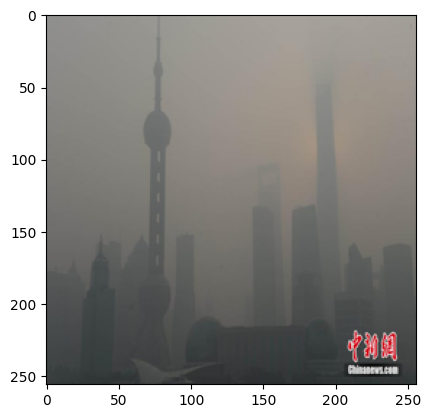

In [4]:
index = 100
weather_search = {i:j for j, i in weather_labels.items()}
plt.imshow(images[index])
print(weather_search[labels[index]], ':', labels[index])

In [5]:
x, y = np.array(images), np.array(labels)

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, test_size=0.2, random_state=123, shuffle=False)
x_train, x_test = x_train/255, x_test/255

In [7]:
def OneHotEncoder(list):
    y_train_ohe = []
    for i in list:
        temp = np.zeros(shape=(11,))
        temp[i-1] = 1
        y_train_ohe.append(temp)
    y_train_ohe = np.array(y_train_ohe)
    return y_train_ohe
    
y_train = OneHotEncoder(y_train)
y_test = OneHotEncoder(y_test)
# plt.hist(y_train)
# plt.show()

In [11]:
input_shape = x_train.shape[1:]

model = Sequential()
model.add( Conv2D(16, kernel_size=(3, 3), input_shape=input_shape, activation='relu') )
model.add( MaxPool2D(pool_size=(2, 2)) )
model.add( Conv2D(32, kernel_size=(3, 3), activation='relu') )
model.add( MaxPool2D(pool_size=(2, 2)) )
model.add( Conv2D(64, kernel_size=(3, 3), activation='relu') )
model.add( MaxPool2D(pool_size=(2, 2)) )
model.add( Conv2D(128, kernel_size=(3, 3), activation='relu') )
model.add( MaxPool2D(pool_size=(2, 2)) )

model.add( Flatten() )
model.add( Dense(128) )
model.add( Dropout(0.2) )
model.add( Dense(64) )
model.add( Dense(32) )
model.add ( Dense(16) )
model.add( Dropout(0.2) )
model.add( Dense(11, activation='softmax') )

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 254, 254, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 127, 127, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 125, 125, 32)        │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 62, 62, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 60, 60, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 11)                  │             187 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,319,883 (12.66 MB)

 Trainable params: 3,319,883 (12.66 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
batch_size = 32
epochs = 30
callback = EarlyStopping(monitor='val_loss', patience=5)

model.compile( optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'] )
history = model.fit(
    x = x_train,
    y = y_train,
    validation_data = (x_test, y_test),
    shuffle = True,
    batch_size = batch_size,
    epochs = epochs,
    verbose = 1,
    callbacks = callback
)

Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 177s 3s/step - accuracy: 0.1832 - loss: 5.6732 - val_accuracy: 0.3601 - val_loss: 1.9404
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 148s 2s/step - accuracy: 0.4548 - loss: 1.7219 - val_accuracy: 0.5636 - val_loss: 1.3974
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.5362 - loss: 1.4155 - val_accuracy: 0.5597 - val_loss: 1.3672
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.6238 - loss: 1.2135 - val_accuracy: 0.6184 - val_loss: 1.2087
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.6585 - loss: 1.0097 - val_accuracy: 0.6067 - val_loss: 1.2862
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.7310 - loss: 0.8056 - val_accuracy: 0.6125 - val_loss: 1.2650
Epoch 7/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.8077 - loss: 0.6232 - val_accuracy: 0.5812 - val_loss: 1.5732
Epoch 8/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 153302s 2432s/step - accuracy: 0.8520 - loss: 0.4927 - val_accuracy: 0.61

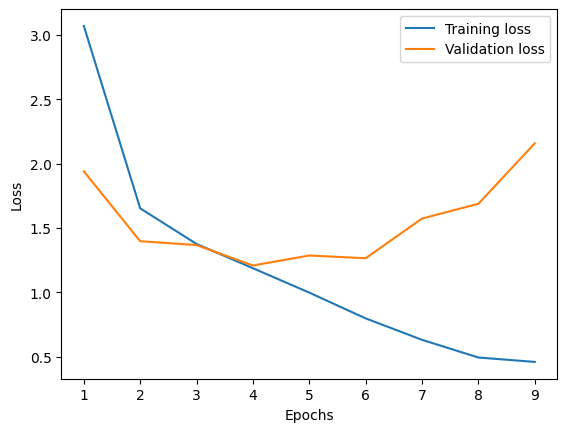

In [12]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss)+1)

fig, ax = plt.subplots()
ax.plot(epochs, loss, label='Training loss')
ax.plot(epochs, val_loss, label='Validation loss')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.set_xticks(epochs)
plt.show()

In [13]:
predictions = model.predict(x_test)
y_test = np.argmax(y_test, axis=1)
predictions = np.argmax(predictions, axis=1)

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 205ms/step


In [14]:
confusion_matrix(y_test, predictions)

array([[ 3,  0,  0,  0,  1,  0, 34,  5,  2,  0,  1],
       [ 0,  0,  0,  0,  0,  0, 46,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0, 37,  7,  1,  0,  0],
       [ 1,  0,  0,  0,  0,  1, 39,  3,  2,  0,  0],
       [ 0,  0,  0,  0,  0,  0, 29, 10,  6,  0,  1],
       [ 3,  0,  0,  1,  0,  0, 27,  8,  5,  0,  2],
       [ 6,  0,  0,  0,  0,  0, 32,  7,  2,  0,  0],
       [ 2,  0,  0,  0,  0,  0, 32, 12,  1,  0,  0],
       [ 0,  0,  0,  0,  0,  0, 41,  6,  0,  0,  0],
       [ 2,  0,  0,  2,  0,  0, 38,  5,  0,  0,  0],
       [ 3,  0,  0,  0,  0,  0, 30, 12,  1,  0,  1]], dtype=int64)